In [4]:
import os
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import numpy as np
import torchvision
from torchvision.transforms import v2
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from tqdm import tqdm
# CONSTANTS
# CONSTANTS
plt.style.use('dark_background')

EXAMPLES_FOR_PLOT = 5
LATENT_SIZE = 64
BATCH_SIZE = 64
EPOCHS = 100
DEVICE = "cpu"

if torch.cuda.is_available():
    DEVICE = "cuda"

LOCAL_DATA_PATH = ".local_data"
DATASET_PATH = f"{LOCAL_DATA_PATH}/datasets"
WEIGHTS_PATH = f"{LOCAL_DATA_PATH}/model_weights"
LOGS_PATH = f"{LOCAL_DATA_PATH}/logs"
os.makedirs(DATASET_PATH, exist_ok=True)
os.makedirs(WEIGHTS_PATH, exist_ok=True)
os.makedirs(LOGS_PATH, exist_ok=True)

# DATA PREP
transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Lambda(lambda t: t/255) # TODO normal scaling
])
train_data = torchvision.datasets.CelebA(DATASET_PATH, download=True, transform=transform, split="train")
test_data = torchvision.datasets.CelebA(DATASET_PATH, download=True, transform=transform, split="test")

train_dataloader = DataLoader(train_data, BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_data, BATCH_SIZE, shuffle=False)

# getting EXAMPLES_FOR_PLOT examples for plotting, TODO rewrite
examples = None
for X, _ in test_dataloader:
    examples = X[:EXAMPLES_FOR_PLOT, :].to(DEVICE)
    break
# MODEL

class VAE(nn.Module):
    def __init__(self, latent_dim=64, hidden_dim=256):
        super().__init__()
        self.latent_dim = latent_dim
        self.feature_shape = (256, 6, 5)  # channels, height, width

        # Encoder convolutional layers (4 strided conv blocks)
        self.encoder_conv = nn.Sequential(
            # 3 x 218 x 178 -> 32 x 109 x 89
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2, inplace=True),
            # 32 x 109 x 89 -> 64 x 54 x 44
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),
            # 64 x 54 x 44 -> 128 x 27 x 22
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            # 128 x 27 x 22 -> 256 x 13 x 11
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.AdaptiveAvgPool2d((6, 5)),   # force stable bottleneck size
        )

        # Encoder fully-connected layers
        self.encoder_fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 6 * 5, hidden_dim),
            nn.LeakyReLU(0.2, inplace=True),
        )

        # Latent space heads
        self.mu_head = nn.Linear(hidden_dim, latent_dim)
        self.logvar_head = nn.Linear(hidden_dim, latent_dim)

        # Decoder fully-connected layer
        self.decoder_fc = nn.Sequential(
            nn.Linear(latent_dim, 256 * 6 * 5),
            nn.LeakyReLU(0.2, inplace=True),
        )

        # Decoder upsampling blocks (each: bilinear upsample + conv)
        # Target sizes for each upsampling step
        self.decoder_target_sizes = [(13, 11), (27, 22), (54, 44), (109, 89), (218, 178)]
        # Corresponding convolution blocks (in_ch, out_ch)
        conv_blocks = [
            nn.Sequential(
                nn.Conv2d(256, 128, kernel_size=3, padding=1),
                nn.BatchNorm2d(128),
                nn.LeakyReLU(0.2, inplace=True),
            ),
            nn.Sequential(
                nn.Conv2d(128, 64, kernel_size=3, padding=1),
                nn.BatchNorm2d(64),
                nn.LeakyReLU(0.2, inplace=True),
            ),
            nn.Sequential(
                nn.Conv2d(64, 32, kernel_size=3, padding=1),
                nn.BatchNorm2d(32),
                nn.LeakyReLU(0.2, inplace=True),
            ),
            nn.Sequential(
                nn.Conv2d(32, 32, kernel_size=3, padding=1),
                nn.BatchNorm2d(32),
                nn.LeakyReLU(0.2, inplace=True),
            ),
            nn.Sequential(
                nn.Conv2d(32, 32, kernel_size=3, padding=1),
                nn.BatchNorm2d(32),
                nn.LeakyReLU(0.2, inplace=True),
            ),
        ]
        self.decoder_blocks = nn.ModuleList(conv_blocks)

        # Final output layer
        self.final_layer = nn.Sequential(
            nn.Conv2d(32, 3, kernel_size=3, padding=1),
            nn.Sigmoid(),   # assumes input images scaled to [0,1]
        )

    def encode(self, x):
        x = self.encoder_conv(x)
        x = self.encoder_fc(x)
        mu = self.mu_head(x)
        logvar = self.logvar_head(x)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std).to(DEVICE)
        return mu + eps * std

    def decode(self, z):
        x = self.decoder_fc(z)
        x = x.view(-1, *self.feature_shape)
        for target_size, block in zip(self.decoder_target_sizes, self.decoder_blocks):
            x = F.interpolate(x, size=target_size, mode='bilinear', align_corners=False)
            x = block(x)
        return self.final_layer(x)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar

class ELBOLoss(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, y, y_prim, mu, std):
        # kl = torch.mean(-0.5 * torch.sum(1 + torch.log(std**2) - mu**2 - std**2, dim=1))

        mse_loss = F.mse_loss(y, y_prim)
        kld_loss = torch.mean(-0.5 * torch.sum(1 + std - mu ** 2 - std.exp(), dim=1), dim=0)
        kld_weight = 1

        # kld_loss = torch.mean(-0.5 * torch.sum(1 + log_var - mu ** 2 - log_var.exp(), dim = 1), dim = 0)

        loss = mse_loss + kld_weight * kld_loss
        return mse_loss, kld_loss

model = VAE(LATENT_SIZE)
model.load_state_dict(torch.load(f"{WEIGHTS_PATH}/vae_celeba.pt", weights_only=True))
model.eval()

FileNotFoundError: [Errno 2] No such file or directory: '.local_data/model_weights/vae_celeba.pt'

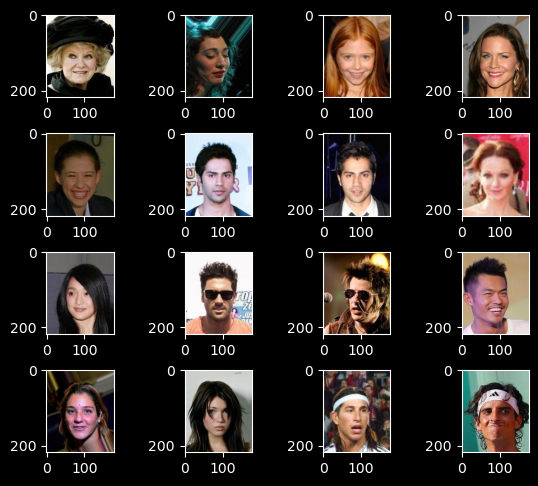

In [7]:
# generating number 1
x_to_encode = []
for idx in range(16):
    x_to_encode.append(test_data[idx][0])

plt_rows = int(np.ceil(np.sqrt(len(x_to_encode))))
for i in range(len(x_to_encode)):
    plt.subplot(plt_rows, plt_rows, i + 1)
    x = (x_to_encode[i] * 255).permute(1, 2, 0)
    plt.imshow(x,)
    plt.tight_layout(pad=0.5)
plt.show()

In [ ]:
GENERATE_COUNT = 16

x_tensor = torch.stack(x_to_encode)
z_mu, z_std = model.encode(x_tensor)
zs = model.reparameterize(z_mu, z_std)
z_mu = torch.mean(zs, dim=0)
z_sigma = torch.std(zs, dim=0)

# sample new letters
z_generated = []
dist = torch.distributions.Normal(z_mu, z_sigma)
for i in range(GENERATE_COUNT):
    if i == 0:
        z = z_mu
    else:
        z = dist.sample()
    z_generated.append(z)
z = torch.stack(z_generated)

x_generated = model.decode(z).permute(0, 2, 3, 1)

plt_rows = int(np.ceil(np.sqrt(GENERATE_COUNT)))
for i in tqdm(range(GENERATE_COUNT)):
    plt.subplot(plt_rows, plt_rows, i + 1)
    plt.imshow(x_generated[i].cpu().squeeze().detach().numpy(), cmap="gray")
    if i == 0:
        plt.title(f"mean")
    else:
        plt.title(f"generated")
    plt.tight_layout(pad=0.5)
plt.show()